<a href="https://colab.research.google.com/github/10decn/Lab-5/blob/main/lab5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier

sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)

DATA_PATH = "wnba-shots-2021.xlsx"
df = pd.read_excel(DATA_PATH)

df.head(10)

,game_id,game_play_number,desc,shot_type,made_shot,shot_value,coordinate_x,coordinate_y,shooting_team,home_team_name,away_team_name,home_score,away_score,qtr,quarter_seconds_remaining,game_seconds_remaining
0,401391650,4,Shatori Walker-Kimbrough blocks Destanni Hende...,Jump Shot,False,0,37,9,Indiana,Washington,Indiana,0,0,1,571,2371
1,401391650,7,Elena Delle Donne misses two point shot,Turnaround Bank Jump Shot,False,0,12,0,Washington,Washington,Indiana,0,0,1,551,2351
2,401391650,9,Tiffany Mitchell makes 4-foot layup (Destanni ...,Cutting Layup Shot,True,2,29,2,Indiana,Washington,Indiana,0,2,1,538,2338
3,401391650,10,Natasha Cloud makes driving layup,Driving Layup Shot,True,2,22,0,Washington,Washington,Indiana,2,2,1,524,2324
4,401391650,11,Tiffany Mitchell makes 26-foot three point jum...,Jump Shot,True,3,9,21,Indiana,Washington,Indiana,2,5,1,512,2312
5,401391650,12,Natasha Cloud makes layup (Myisha Hines-Allen ...,Cutting Layup Shot,True,2,27,0,Washington,Washington,Indiana,4,5,1,490,2290
6,401391650,13,Kelsey Mitchell makes driving layup,Driving Layup Shot,True,2,22,3,Indiana,Washington,Indiana,4,7,1,478,2278
7,401391650,15,Kelsey Mitchell makes free throw 1 of 1,Free Throw - 1 of 1,True,1,-214748340,-214748365,Indiana,Washington,Indiana,4,8,1,478,2278
8,401391650,16,Shatori Walker-Kimbrough makes 14-foot pullup ...,Pullup Jump Shot,True,2,12,4,Washington,Washington,Indiana,6,8,1,461,2261
9,401391650,17,NaLyssa Smith misses 20-foot pullup jump shot,Pullup Jump Shot,False,0,13,16,Indiana,Washington,Indiana,6,8,1,436,2236


In [14]:
print("Shape:", df.shape)
print("\nMissing values per column:")
display(df.isna().sum().to_frame("missing_count").T)

print("\nDuplicate rows:", df.duplicated().sum())

Shape: (41497, 16)

Missing values per column:


,game_id,game_play_number,desc,shot_type,made_shot,shot_value,coordinate_x,coordinate_y,shooting_team,home_team_name,away_team_name,home_score,away_score,qtr,quarter_seconds_remaining,game_seconds_remaining
missing_count,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0



Duplicate rows: 0


In [15]:
target_col = "made_shot"
df[target_col].value_counts()

,count
made_shot,
True,21405
False,20092


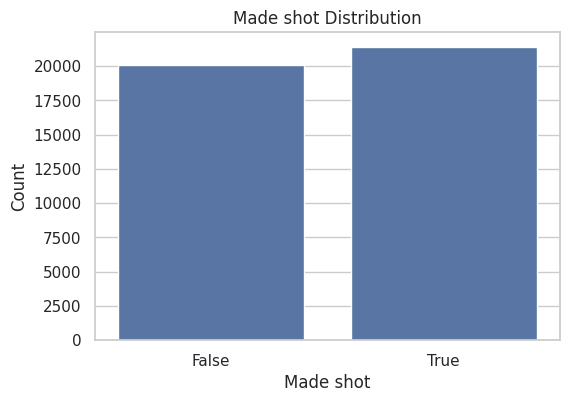

In [16]:
plt.figure(figsize=(6,4))
sns.countplot(x=target_col, data=df)
plt.title("Made shot Distribution")
plt.xlabel("Made shot")
plt.ylabel("Count")
plt.show()

In [17]:
df.dtypes

,0
game_id,int64
game_play_number,int64
desc,object
shot_type,object
made_shot,bool
shot_value,int64
coordinate_x,int64
coordinate_y,int64
shooting_team,object
home_team_name,object


In [18]:
drop_cols = ["shot_value", "home_score"]

# keep only existing columns
drop_cols = [c for c in drop_cols if c in df.columns]

# drop from dataframe
df = df.drop(columns=drop_cols)

In [20]:
df_fe = df.copy()

# Calculate elapsed time in the game (in seconds)
df_fe["time_elapsed"] = (4 - df_fe["qtr"]) * 720 + (720 - df_fe["quarter_seconds_remaining"])

# Convert to minutes
df_fe["game_minute"] = df_fe["time_elapsed"] / 60

# Divide the game into periods
df_fe["period_in_game"] = pd.cut(df_fe["game_minute"],
                                  bins=[0, 12, 24, 36, 48],
                                  labels=["Q1", "Q2", "Q3", "Q4"])

# Is it clutch time? (Last 2 minutes of game OR last 30 seconds of quarter)
df_fe["is_clutch_time"] = ((df_fe["quarter_seconds_remaining"] <= 30) |
                           (df_fe["game_seconds_remaining"] <= 120)).astype(int)

# Is it the start of a quarter? (First minute)
df_fe["is_start_of_quarter"] = (df_fe["quarter_seconds_remaining"] >= 660).astype(int)

# Time remaining in quarter (in minutes)
df_fe["quarter_minutes_remaining"] = df_fe["quarter_seconds_remaining"] / 60

# Display new features
features_to_show = ["qtr", "quarter_seconds_remaining", "game_seconds_remaining",
                    "game_minute", "period_in_game", "is_clutch_time", "is_start_of_quarter"]
df_fe[features_to_show].head(10)

,qtr,quarter_seconds_remaining,game_seconds_remaining,game_minute,period_in_game,is_clutch_time,is_start_of_quarter
0,1,571,2371,38.483333,Q4,0,0
1,1,551,2351,38.816667,Q4,0,0
2,1,538,2338,39.033333,Q4,0,0
3,1,524,2324,39.266667,Q4,0,0
4,1,512,2312,39.466667,Q4,0,0
5,1,490,2290,39.833333,Q4,0,0
6,1,478,2278,40.033333,Q4,0,0
7,1,478,2278,40.033333,Q4,0,0
8,1,461,2261,40.316667,Q4,0,0
9,1,436,2236,40.733333,Q4,0,0


In [26]:
df_fe[["qtr", "quarter_seconds_remaining", "game_seconds_remaining",
       "game_minute", "period_in_game", "is_clutch_time", "is_start_of_quarter"]].head(10)

,qtr,quarter_seconds_remaining,game_seconds_remaining,game_minute,period_in_game,is_clutch_time,is_start_of_quarter
0,1,571,2371,38.483333,Q4,0,0
1,1,551,2351,38.816667,Q4,0,0
2,1,538,2338,39.033333,Q4,0,0
3,1,524,2324,39.266667,Q4,0,0
4,1,512,2312,39.466667,Q4,0,0
5,1,490,2290,39.833333,Q4,0,0
6,1,478,2278,40.033333,Q4,0,0
7,1,478,2278,40.033333,Q4,0,0
8,1,461,2261,40.316667,Q4,0,0
9,1,436,2236,40.733333,Q4,0,0


In [27]:
df['shot_type'].unique()

array(['Jump Shot', 'Turnaround Bank Jump Shot', 'Cutting Layup Shot',
       'Driving Layup Shot', 'Free Throw - 1 of 1', 'Pullup Jump Shot',
       'Alley Oop Dunk Shot', 'Turnaround Jump Shot', 'Layup Shot',
       'Jump Shot Bank', 'Reverse Layup Shot', 'Layup Shot Putback',
       'Free Throw - 1 of 2', 'Free Throw - 2 of 2', 'Hook Shot',
       'Running Layup Shot', 'Step Back Jump Shot',
       'Turnaround Fade Away Jump Shot', 'Fade Away Jump Shot',
       'Floating Jump Shot', 'Driving Floating Jump Shot',
       'Driving Finger Roll Layup', 'Alley Oop Layup Shot',
       'Running Jump Shot', 'Tip Shot', 'Running Pullup Jump Shot',
       'Free Throw - Technical', 'Driving Floating Bank Jump Shot',
       'Layup Driving Reverse', 'Free Throw - 1 of 3',
       'Free Throw - 2 of 3', 'Free Throw - 3 of 3', 'Driving Hook Shot',
       'Turnaround Hook Shot', 'Layup Running Reverse',
       'Running Alley Oop Layup Shot', 'Running Finger Roll Layup',
       'Hook Turnaround Bank',

In [47]:
if "shot_type" in df_fe.columns:
    top_k = 12
    top_items = df_fe["shot_type"].value_counts().head(top_k).index
    df_fe["shot_type_reduced"] = np.where(df_fe["shot_type"].isin(top_items), df_fe["shot_type"], "Other")
    print("Unique shot_type:", df_fe["shot_type"].nunique())
    print("Unique shot_type_reduced:", df_fe["shot_type_reduced"].nunique())
    df_fe[["shot_type", "shot_type_reduced"]].head(10)
else:
    print("shot_type column not found.")

Unique shot_type: 58
Unique shot_type_reduced: 13


In [33]:
print(df_fe.columns.tolist())

['game_id', 'game_play_number', 'desc', 'shot_type', 'made_shot', 'coordinate_x', 'coordinate_y', 'shooting_team', 'home_team_name', 'away_team_name', 'away_score', 'qtr', 'quarter_seconds_remaining', 'game_seconds_remaining', 'time_elapsed', 'game_minute', 'period_in_game', 'is_clutch_time', 'is_start_of_quarter', 'quarter_minutes_remaining', 'shot_type_reduced']


In [34]:
df_fe["time_tier"] = pd.cut(
    df_fe["quarter_seconds_remaining"],
    bins=[0, 200, 400, 600, np.inf],
    labels=["low", "medium", "high", "very_high"]
)

df_fe[["quarter_seconds_remaining", "time_tier"]].head(10)

,quarter_seconds_remaining,time_tier
0,571,high
1,551,high
2,538,high
3,524,high
4,512,high
5,490,high
6,478,high
7,478,high
8,461,high
9,436,high


In [35]:
df_fe.head()

,game_id,game_play_number,desc,shot_type,made_shot,coordinate_x,coordinate_y,shooting_team,home_team_name,away_team_name,away_score,qtr,quarter_seconds_remaining,game_seconds_remaining,time_elapsed,game_minute,period_in_game,is_clutch_time,is_start_of_quarter,quarter_minutes_remaining,shot_type_reduced,time_tier
0,401391650,4,Shatori Walker-Kimbrough blocks Destanni Hende...,Jump Shot,False,37,9,Indiana,Washington,Indiana,0,1,571,2371,2309,38.483333,Q4,0,0,9.516667,Jump Shot,high
1,401391650,7,Elena Delle Donne misses two point shot,Turnaround Bank Jump Shot,False,12,0,Washington,Washington,Indiana,0,1,551,2351,2329,38.816667,Q4,0,0,9.183333,Other,high
2,401391650,9,Tiffany Mitchell makes 4-foot layup (Destanni ...,Cutting Layup Shot,True,29,2,Indiana,Washington,Indiana,2,1,538,2338,2342,39.033333,Q4,0,0,8.966667,Cutting Layup Shot,high
3,401391650,10,Natasha Cloud makes driving layup,Driving Layup Shot,True,22,0,Washington,Washington,Indiana,2,1,524,2324,2356,39.266667,Q4,0,0,8.733333,Driving Layup Shot,high
4,401391650,11,Tiffany Mitchell makes 26-foot three point jum...,Jump Shot,True,9,21,Indiana,Washington,Indiana,5,1,512,2312,2368,39.466667,Q4,0,0,8.533333,Jump Shot,high


In [36]:
drop_cols = [
    "game_id", "game_play_number", "desc", "shooting_team", "home_team_name", "away_team_name",
    "shot_type"  # we replaced it with shot_type_reduced
]

# keep only columns that exist (safe for future versions of the dataset)
drop_cols = [c for c in drop_cols if c in df_fe.columns]

X = df_fe.drop(columns=drop_cols + [target_col])
y = df_fe[target_col]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (41497, 14)
y shape: (41497,)


In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (33197, 14)
Test size: (8300, 14)


In [38]:
target_col = "made_shot"

# Identify categorical and numerical columns automatically
categorical_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = X_train.select_dtypes(include=[np.number, "bool"]).columns.tolist()

print("Categorical columns:\n", categorical_cols,'\n')
print("Numeric columns:\n", numeric_cols)

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols),
    ]
)

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight=None
)

model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("rf", rf)
])

model

Categorical columns:
 ['period_in_game', 'shot_type_reduced', 'time_tier'] 

Numeric columns:
 ['coordinate_x', 'coordinate_y', 'away_score', 'qtr', 'quarter_seconds_remaining', 'game_seconds_remaining', 'time_elapsed', 'game_minute', 'is_clutch_time', 'is_start_of_quarter', 'quarter_minutes_remaining']


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['period_in_game',
                                                   'shot_type_reduced',
                                                   'time_tier']),
                                                 ('num', 'passthrough',
                                                  ['coordinate_x',
                                                   'coordinate_y', 'away_score',
                                                   'qtr',
                                                   'quarter_seconds_remaining',
                                                   'game_seconds_remaining',
                                                   'time_elapsed',
                                                   'game_minute',
                                                   'is_clutch_time',
                                                   'is_start_of_quarter',
                                                   'quarter_minutes_remaining'])])),
                ('rf',
                 RandomForestClassifier(n_estimators=300, n_jobs=-1,
                                        random_state=42))])

In [39]:
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.6176

Classification Report:
              precision    recall  f1-score   support

       False       0.59      0.66      0.63      4019
        True       0.64      0.58      0.61      4281

    accuracy                           0.62      8300
   macro avg       0.62      0.62      0.62      8300
weighted avg       0.62      0.62      0.62      8300



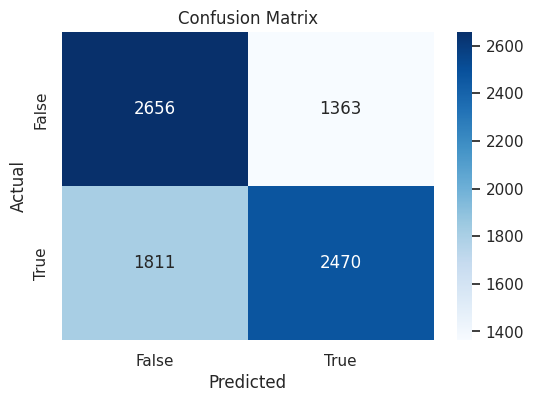

In [40]:
cm = confusion_matrix(y_test, y_pred, labels=model.named_steps["rf"].classes_)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=model.named_steps["rf"].classes_, yticklabels=model.named_steps["rf"].classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [41]:
# Get feature names after preprocessing
ohe = model.named_steps["preprocess"].named_transformers_["cat"]
cat_feature_names = ohe.get_feature_names_out(categorical_cols) if len(categorical_cols) > 0 else np.array([])
all_feature_names = np.concatenate([cat_feature_names, np.array(numeric_cols)])

importances = model.named_steps["rf"].feature_importances_

fi = (pd.DataFrame({"feature": all_feature_names, "importance": importances})
        .sort_values("importance", ascending=False))

fi.head(15)

,feature,importance
22,away_score,0.146032
20,coordinate_x,0.128820
21,coordinate_y,0.124948
25,game_seconds_remaining,0.101794
26,time_elapsed,0.100876
27,game_minute,0.100785
24,quarter_seconds_remaining,0.100654
30,quarter_minutes_remaining,0.100500
9,shot_type_reduced_Jump Shot,0.016993
8,shot_type_reduced_Free Throw - 2 of 2,0.010249


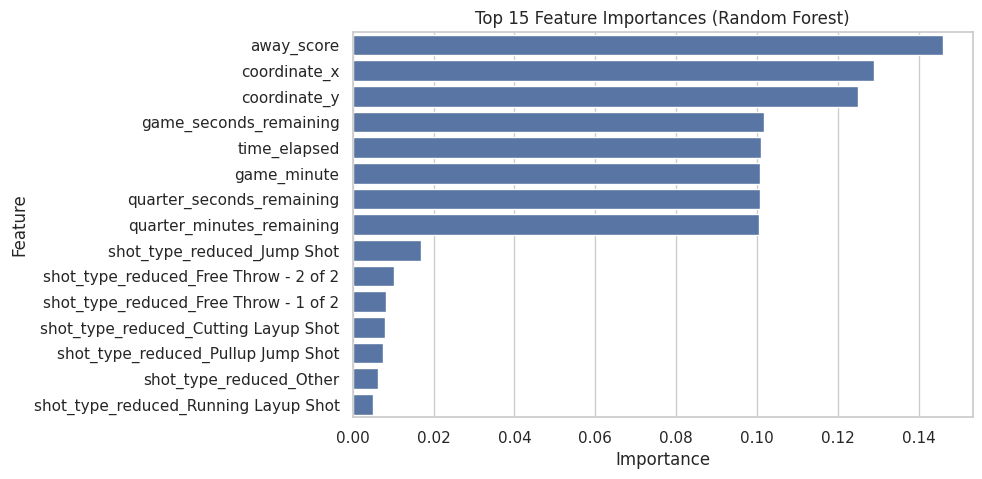

In [42]:
plt.figure(figsize=(8,5))
top_n = 15
sns.barplot(data=fi.head(top_n), x="importance", y="feature")
plt.title(f"Top {top_n} Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()